In [1]:
import pandas as pd
import seaborn as sns
data = sns.load_dataset("titanic")

In [2]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
data.shape

(891, 15)

In [5]:
data.describe(

)

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
data['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [7]:
data.describe(include="object")

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [8]:
data["sex"].unique()

array(['male', 'female'], dtype=object)

In [9]:
data["class"].unique()

['Third', 'First', 'Second']
Categories (3, object): ['First', 'Second', 'Third']

In [10]:
data["embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [11]:
data["sex"].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

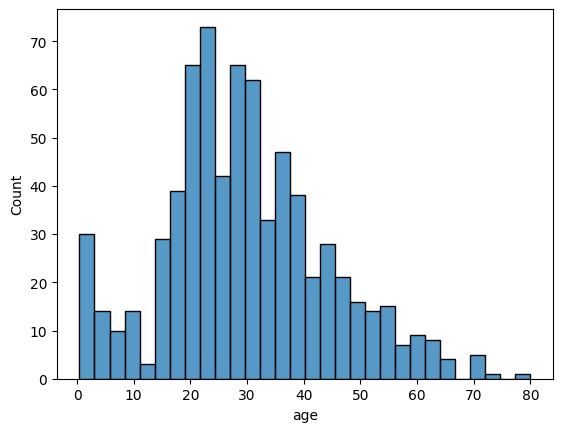

In [12]:
import matplotlib.pyplot as plt
sns.histplot(data , x="age" , bins=30)
plt.show()

In [13]:
data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

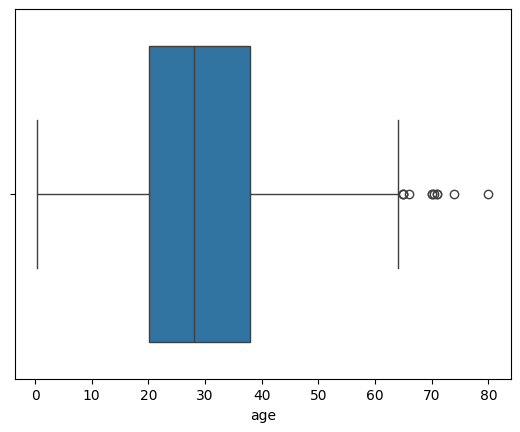

In [14]:
sns.boxplot(data , x="age")
plt.show()

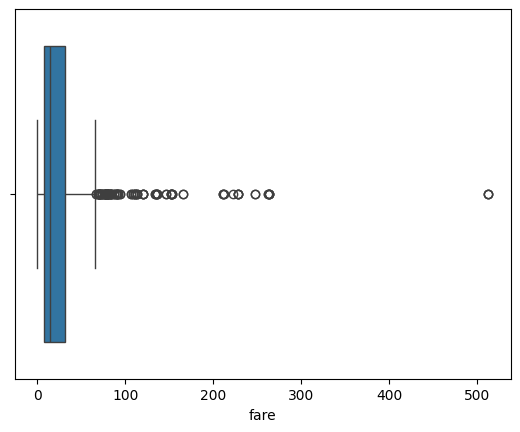

In [15]:
sns.boxplot(data , x="fare")
plt.show()

In [16]:
Q1=data['fare'].quantile(0.25)
Q3=data['fare'].quantile(0.75)
IQR = Q3 - Q1
lower=Q1 - 1.5*IQR
upper=Q3 + 1.5*IQR
outliers = data[(data['fare']<lower) | (data['fare']>upper) ]
len(outliers)

116

In [17]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

In [18]:
target="survived"

In [19]:
data["family_size"] = data["sibsp"] + data["parch"] + 1

In [20]:
data[["sibsp", "parch", "family_size"]].head(10)

,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


In [21]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked",
    "family_size"
]
X=data[features]
y=data[target]

In [22]:
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked,family_size
0,3,male,22.0,1,0,7.2500,S,2
1,1,female,38.0,1,0,71.2833,C,2
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,2
4,3,male,35.0,0,0,8.0500,S,1


In [23]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X , y , test_size=0.2 , random_state=42 , stratify=y
)

In [25]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(712, 8)
(179, 8)
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [26]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "family_size"
]

categorical_features = [
    "sex",
    "embarked"
]

In [27]:
from sklearn.impute import  SimpleImputer
numeric_transformer = SimpleImputer(strategy="median"
)

In [28]:
from sklearn.preprocessing import OneHotEncoder
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

In [29]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
model=Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42, n_estimators=100))
    ]
)

In [31]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [32]:
y_pred=model.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test, y_pred)
print("accuracy" , accuracy)

accuracy 0.8156424581005587


In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[96 14]
 [19 50]]


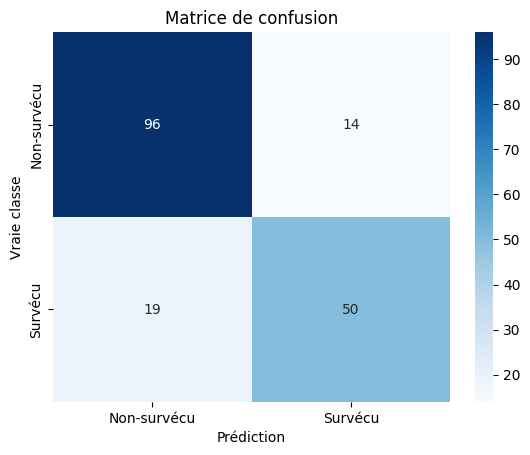

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-survécu", "Survécu"],
    yticklabels=["Non-survécu", "Survécu"]
)

plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.title("Matrice de confusion")
plt.show()

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [38]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importances = model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feature_importance)

              feature  importance
4           num__fare    0.250912
1            num__age    0.243762
7       cat__sex_male    0.147459
6     cat__sex_female    0.129822
0         num__pclass    0.083577
5    num__family_size    0.051271
2          num__sibsp    0.030118
3          num__parch    0.026856
10    cat__embarked_S    0.015848
8     cat__embarked_C    0.013199
9     cat__embarked_Q    0.007152
11  cat__embarked_nan    0.000025


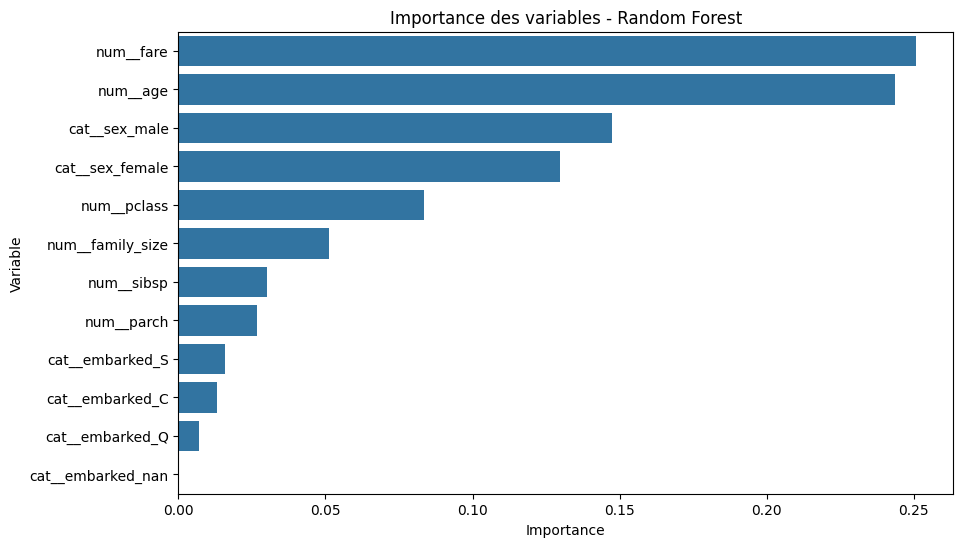

In [39]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature"
)

plt.title("Importance des variables - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()

In [40]:
from sklearn.model_selection import cross_val_score 
scores = cross_val_score(model , X , y , cv =5 , scoring="accuracy")
print("cross validation scores :", scores)
print("mean accuracy :", scores.mean())
print("standard deviation :", scores.std())


cross validation scores : [0.77094972 0.80337079 0.85955056 0.78651685 0.82022472]
mean accuracy : 0.8081225284037412
standard deviation : 0.03053688750853695
